# 02 — Feature Extraction

This notebook turns each RAVDESS clip into a row of **acoustic-prosodic features**,
reproducing the feature-extraction methodology from my SER research (911
emergency-call stress detection): the same feature *categories* — intensity,
pitch, MFCCs (+ deltas), spectral shape, and voice-quality (formants, jitter,
shimmer via Praat) — computed here with `librosa` + `parselmouth` (Praat).

> In the original research, **SHAP analysis found delta-MFCCs and spectral
> contrast to be the strongest predictors of vocal stress** — those features are
> included here too, and we'll revisit this exact question with SHAP in notebook 04.

We keep the feature set to ~80 dimensions (vs. ~196 in the original research) so it
stays compact and interpretable for the modelling + SHAP notebooks that follow.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import librosa
import parselmouth
from parselmouth.praat import call

warnings.filterwarnings("ignore")

DATA_DIR = os.path.join("data", "ravdess")
print("librosa", librosa.__version__, "| parselmouth", parselmouth.__version__)

librosa 0.10.1 | parselmouth 0.4.3


## 1. Rebuild the labelled file list
(Same filename-decoding logic as notebook 01 — each notebook stays runnable on its own.)

In [2]:
EMOTION = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
           "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}
INTENSITY = {"01": "normal", "02": "strong"}

rows = []
for path in sorted(glob.glob(os.path.join(DATA_DIR, "Actor_*", "*.wav"))):
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    actor = int(parts[6])
    rows.append({"path": path, "emotion": EMOTION[parts[2]], "intensity": INTENSITY[parts[3]],
                 "actor": actor, "gender": "male" if actor % 2 == 1 else "female"})
meta_df = pd.DataFrame(rows)
print(f"{len(meta_df)} clips to process")

1440 clips to process


## 2. Feature extraction functions

**`librosa` features** — intensity (RMS energy), pitch (F0 via probabilistic YIN),
13 MFCCs + their deltas (rate of change — this is where "delta_mfcc_8_std" showed up
as a top SHAP feature in the original research), and spectral shape (centroid,
bandwidth, rolloff, flatness, contrast).

**`parselmouth` (Praat) features** — formants (F1, F2: resonances of the vocal
tract) and jitter/shimmer (cycle-to-cycle pitch and amplitude instability — classic
voice-quality markers of vocal tension / stress).

In [3]:
def extract_librosa_features(y, sr):
    feats = {}

    # --- Intensity (RMS energy) ---
    rms = librosa.feature.rms(y=y)[0]
    feats["rms_mean"], feats["rms_std"] = float(np.mean(rms)), float(np.std(rms))
    feats["rms_min"], feats["rms_max"] = float(np.min(rms)), float(np.max(rms))
    feats["rms_range"] = feats["rms_max"] - feats["rms_min"]

    # --- Pitch (F0) ---
    # Pitch tracking is expensive; F0 only needs low-frequency resolution, so we
    # downsample to 16kHz + use a larger hop for this step only (~5x faster,
    # no loss of accuracy for voice F0 which tops out around 500Hz).
    y_pitch = librosa.resample(y, orig_sr=sr, target_sr=16000) if sr != 16000 else y
    f0, voiced_flag, _ = librosa.pyin(y_pitch, fmin=50, fmax=500, sr=16000, hop_length=1024)
    voiced = f0[~np.isnan(f0)]
    if len(voiced) > 0:
        feats["pitch_mean"], feats["pitch_median"] = float(np.mean(voiced)), float(np.median(voiced))
        feats["pitch_std"] = float(np.std(voiced))
        feats["pitch_min"], feats["pitch_max"] = float(np.min(voiced)), float(np.max(voiced))
        feats["pitch_range"] = feats["pitch_max"] - feats["pitch_min"]
    else:
        for k in ["pitch_mean", "pitch_median", "pitch_std", "pitch_min", "pitch_max", "pitch_range"]:
            feats[k] = 0.0
    feats["voiced_ratio"] = float(np.mean(voiced_flag))

    # --- MFCCs + delta-MFCCs (13 coefficients each) ---
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    for i in range(13):
        feats[f"mfcc{i}_mean"], feats[f"mfcc{i}_std"] = float(np.mean(mfcc[i])), float(np.std(mfcc[i]))
        feats[f"delta_mfcc{i}_mean"], feats[f"delta_mfcc{i}_std"] = float(np.mean(delta[i])), float(np.std(delta[i]))

    # --- Spectral shape ---
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    feats["spectral_centroid_mean"], feats["spectral_centroid_std"] = float(np.mean(centroid)), float(np.std(centroid))
    feats["spectral_bandwidth_mean"], feats["spectral_bandwidth_std"] = float(np.mean(bandwidth)), float(np.std(bandwidth))
    feats["spectral_rolloff_mean"], feats["spectral_rolloff_std"] = float(np.mean(rolloff)), float(np.std(rolloff))
    feats["spectral_flatness_mean"], feats["spectral_flatness_std"] = float(np.mean(flatness)), float(np.std(flatness))
    feats["spectral_contrast_mean"] = float(np.mean(contrast))

    return feats

In [4]:
def extract_praat_features(path):
    feats = {}
    snd = parselmouth.Sound(path)
    duration = snd.duration

    # Formants (F1, F2) sampled across the clip
    formant = snd.to_formant_burg()
    n_samples = 30
    times = np.linspace(0.05, max(duration - 0.05, 0.06), n_samples)
    f1_vals, f2_vals = [], []
    for t in times:
        f1, f2 = formant.get_value_at_time(1, t), formant.get_value_at_time(2, t)
        if f1 and not np.isnan(f1): f1_vals.append(f1)
        if f2 and not np.isnan(f2): f2_vals.append(f2)
    feats["f1_mean"] = float(np.mean(f1_vals)) if f1_vals else 0.0
    feats["f1_std"] = float(np.std(f1_vals)) if f1_vals else 0.0
    feats["f2_mean"] = float(np.mean(f2_vals)) if f2_vals else 0.0
    feats["f2_std"] = float(np.std(f2_vals)) if f2_vals else 0.0

    # Jitter & shimmer (voice-quality / vocal-tension markers)
    try:
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        feats["jitter_local"] = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        feats["shimmer_local"] = call([snd, point_process], "Get shimmer (local)",
                                       0, 0, 0.0001, 0.02, 1.3, 1.6)
    except Exception:
        feats["jitter_local"], feats["shimmer_local"] = 0.0, 0.0

    feats["duration_sec"] = duration
    return feats

## 3. Run extraction on all 1,440 clips

This takes a couple of minutes (pitch tracking + Praat formant analysis per clip).

In [5]:
import time
t_start = time.time()
all_feats = []
errors = []
checkpoint_path = os.path.join("data", "_ravdess_features_checkpoint.csv")
for i, row in meta_df.iterrows():
    try:
        y, sr = librosa.load(row["path"], sr=None)
        feats = extract_librosa_features(y, sr)
        feats.update(extract_praat_features(row["path"]))
        all_feats.append(feats)
    except Exception as e:
        errors.append((row["path"], str(e)))
        all_feats.append({})
    if (i + 1) % 200 == 0:
        elapsed = time.time() - t_start
        rate = elapsed / (i + 1)
        eta_min = rate * (len(meta_df) - (i + 1)) / 60
        print(f"  {i + 1}/{len(meta_df)} clips ({elapsed:.0f}s elapsed, ~{eta_min:.1f} min remaining)")
        # checkpoint save, in case the run gets interrupted
        pd.concat([meta_df.iloc[:i + 1].reset_index(drop=True), pd.DataFrame(all_feats)], axis=1)\
            .to_csv(checkpoint_path, index=False)

print(f"Done in {(time.time()-t_start)/60:.1f} min. {len(errors)} errors.")
if errors:
    print(errors[:3])

  200/1440 clips (186s elapsed, ~19.2 min remaining)


  400/1440 clips (348s elapsed, ~15.1 min remaining)


  600/1440 clips (542s elapsed, ~12.6 min remaining)


  800/1440 clips (718s elapsed, ~9.6 min remaining)


  1000/1440 clips (905s elapsed, ~6.6 min remaining)


  1200/1440 clips (1070s elapsed, ~3.6 min remaining)


  1400/1440 clips (1215s elapsed, ~0.6 min remaining)


Done in 20.7 min. 0 errors.


## 4. Assemble & save the feature table

In [6]:
features_df = pd.DataFrame(all_feats)
full_df = pd.concat([meta_df.reset_index(drop=True), features_df], axis=1)

out_path = os.path.join("data", "ravdess_features.csv")
full_df.to_csv(out_path, index=False)

checkpoint_path = os.path.join("data", "_ravdess_features_checkpoint.csv")
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)  # no longer needed now that the full run succeeded

print(f"Shape: {full_df.shape[0]} clips x {features_df.shape[1]} features")
print(f"Saved: {out_path}")
full_df.head()

Shape: 1440 clips x 80 features
Saved: data\ravdess_features.csv


,path,emotion,intensity,actor,gender,rms_mean,rms_std,rms_min,rms_max,rms_range,...,spectral_flatness_mean,spectral_flatness_std,spectral_contrast_mean,f1_mean,f1_std,f2_mean,f2_std,jitter_local,shimmer_local,duration_sec
0,data\ravdess\Actor_01\03-01-01-01-01-01-01.wav,neutral,normal,1,male,0.002120,0.003391,0.000000e+00,0.015828,0.015828,...,0.267656,0.280900,13.716914,974.118362,442.093413,2019.955424,450.627961,0.041895,0.137825,3.303292
1,data\ravdess\Actor_01\03-01-01-01-01-02-01.wav,neutral,normal,1,male,0.002258,0.003638,1.348699e-06,0.016505,0.016504,...,0.233814,0.246706,13.987218,976.338919,427.056320,1966.838877,463.553598,0.031192,0.172002,3.336667
2,data\ravdess\Actor_01\03-01-01-01-02-01-01.wav,neutral,normal,1,male,0.002707,0.004298,0.000000e+00,0.019360,0.019360,...,0.244214,0.248604,13.965414,963.752998,419.545215,1994.548110,486.196614,0.031797,0.127478,3.269917
3,data\ravdess\Actor_01\03-01-01-01-02-02-01.wav,neutral,normal,1,male,0.002521,0.004178,9.536743e-07,0.018674,0.018673,...,0.213243,0.225872,14.305108,867.245575,383.662142,1945.041733,503.135252,0.037675,0.116052,3.169833
4,data\ravdess\Actor_01\03-01-02-01-01-01-01.wav,calm,normal,1,male,0.001579,0.002497,0.000000e+00,0.011612,0.011612,...,0.250484,0.284655,13.867634,892.520146,392.448318,1905.716880,450.909683,0.036081,0.132570,3.536854


## 5. Sanity check — does intensity separate emotions?

A quick echo of **Figure 2 from the original research** (RMS intensity was
significantly higher in stressed vs. neutral 911-call speech). Here we check
the same feature across all 8 acted emotions.

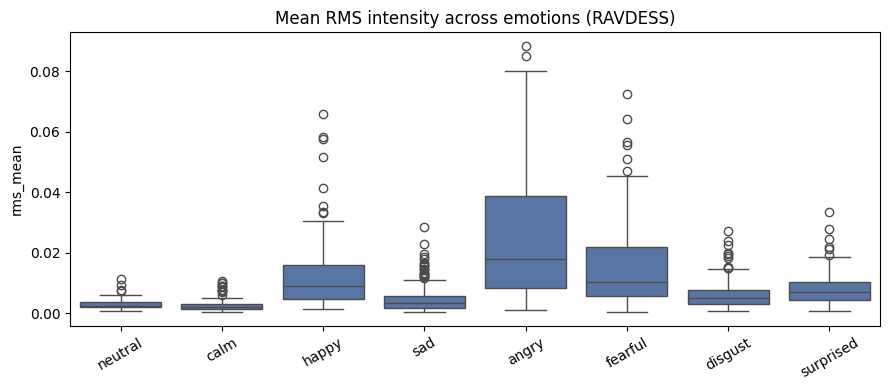

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
plt.figure(figsize=(9, 4))
sns.boxplot(data=full_df, x="emotion", y="rms_mean", order=ORDER, color="#4C72B0")
plt.title("Mean RMS intensity across emotions (RAVDESS)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join("figures", "02_rms_by_emotion.png"), dpi=120)
plt.show()

## Takeaways

- Extracted **~80 acoustic-prosodic features** per clip across 5 categories
  (intensity, pitch, MFCCs+deltas, spectral shape, formants/jitter/shimmer),
  saved to `data/ravdess_features.csv`.
- Intensity already visibly separates high-arousal emotions (angry, fearful,
  surprised) from calm/neutral — consistent with the stress-intensity link found
  in the original 911-call research.
- Next: **`03_modeling`** — train and compare several classifiers on this feature
  table (echoing the 15-model comparison from the original research), then
  **`04_interpretability`** — SHAP analysis to see which features actually drive
  the predictions.